# 06 — Stage 2 Model Training: Fraud Type Classification

## Objective
Train classifiers on fraud-only transactions to identify
WHICH TYPE of fraud occurred — driver fraud, user fraud,
or collusion fraud.

## Context
Stage 2 only runs on transactions that Stage 1 already
flagged as fraud. Its job is not to detect fraud but to
CLASSIFY the detected fraud into actionable categories
so the right investigation team handles it.

## What Makes This Hard
- Only 1,831 training examples (vs 60,000 in Stage 1)
- User fraud signals overlap heavily with legitimate signals
- Three classes with very different signal strengths:
  Driver Fraud   → strong GPS signals (easy to classify)
  Collusion Fraud→ one perfect signal (pair frequency)
  User Fraud     → weak signals only (hardest)

## Models
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost
5. LightGBM

## Primary Metric: Macro F1
Treats all three fraud types equally.
A model cannot score well by ignoring any fraud type.

## Secondary Metrics
- Per-class F1 for Driver / User / Collusion
- 3×3 Confusion Matrix
- Cross Validation (critical with only 1,831 rows)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection  import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    accuracy_score
)
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print("SMOTE available ✅")
except ImportError:
    SMOTE_AVAILABLE = False
    print("⚠️ Install: pip install imbalanced-learn")

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

FRAUD_COLORS = {
    1: "#F44336",   # Driver Fraud
    2: "#FF9800",   # User Fraud
    3: "#9C27B0",   # Collusion Fraud
}
FRAUD_LABELS = {
    1: "Driver Fraud",
    2: "User Fraud",
    3: "Collusion Fraud"
}

print("Libraries loaded ✅")

SMOTE available ✅
Libraries loaded ✅


In [2]:
PATH = "../data/processed/"

modeling_s2 = pd.read_csv(PATH + "modeling_stage2.csv")

with open(PATH + "feature_cols_s2.pkl",  "rb") as f:
    feature_cols_s2 = pickle.load(f)
with open(PATH + "class_weights_s2.pkl", "rb") as f:
    class_weight_s2 = pickle.load(f)

# Keep only numeric features to avoid string/object columns in X
numeric_cols_s2 = modeling_s2.select_dtypes(include=["number"]).columns.tolist()
feature_cols_s2 = [
    c for c in feature_cols_s2
    if c in numeric_cols_s2
    and c != "is_fraud"
]

TARGET = "fraud_label"
X = modeling_s2[feature_cols_s2]
y = modeling_s2[TARGET]

print("Stage 2 data loaded ✅")
print(f"  X shape    : {X.shape}")
print(f"  Features   : {len(feature_cols_s2)}")
print(f"  Total rows : {len(modeling_s2):,}")
print(f"\nClass distribution:")
for k in [1, 2, 3]:
    count = (y == k).sum()
    pct   = count / len(y) * 100
    print(f"  {FRAUD_LABELS[k]:<20}: {count:>5,}  ({pct:.1f}%)")

print(f"\nClass weights: {class_weight_s2}")
print(f"\n⚠️ Only {len(y):,} total rows — "
      f"smallest training set in this entire project")

Stage 2 data loaded ✅
  X shape    : (1831, 53)
  Features   : 53
  Total rows : 1,831

Class distribution:
  Driver Fraud        :   724  (39.5%)
  User Fraud          :   615  (33.6%)
  Collusion Fraud     :   492  (26.9%)

Class weights: {1: np.float64(0.8430018416206262), 2: np.float64(0.9924119241192412), 3: np.float64(1.2405149051490514)}

⚠️ Only 1,831 total rows — smallest training set in this entire project


## Special Considerations for This Notebook

### Why Small Data Changes Everything

With 60,000 rows (Stage 1), we could afford:
- Complex models with many parameters
- Aggressive hyperparameter tuning
- A single 80/20 split as reliable evaluation

With 1,831 rows (Stage 2), we must:
- Use cross-validation as the PRIMARY evaluation method
  (a single 80/20 split is too noisy with so few examples)
- Prefer simpler models — complex models overfit tiny data
- Apply SMOTE aggressively — especially for Collusion (26.9%)
- Be conservative about conclusions — results will have
  higher variance than any previous notebook

### Relabeling Strategy for XGBoost/LightGBM
Our fraud labels are 1, 2, 3.
XGBoost requires class labels starting from 0.
We remap: 1→0, 2→1, 3→2 for training,
then remap back: 0→1, 1→2, 2→3 for evaluation.
This is a technical requirement, not a conceptual change.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # critical with small dataset
)

print("Stratified Train/Test Split ✅")
print(f"\n  Total rows : {len(y):,}")
print(f"  X_train    : {X_train.shape}")
print(f"  X_test     : {X_test.shape}")

print(f"\n  Train class distribution:")
for k in [1, 2, 3]:
    count = (y_train == k).sum()
    pct   = count / len(y_train) * 100
    print(f"    {FRAUD_LABELS[k]:<20}: {count:>4,}  ({pct:.1f}%)")

print(f"\n  Test class distribution:")
for k in [1, 2, 3]:
    count = (y_test == k).sum()
    pct   = count / len(y_test) * 100
    print(f"    {FRAUD_LABELS[k]:<20}: {count:>4,}  ({pct:.1f}%)")

Stratified Train/Test Split ✅

  Total rows : 1,831
  X_train    : (1464, 53)
  X_test     : (367, 53)

  Train class distribution:
    Driver Fraud        :  579  (39.5%)
    User Fraud          :  492  (33.6%)
    Collusion Fraud     :  393  (26.8%)

  Test class distribution:
    Driver Fraud        :  145  (39.5%)
    User Fraud          :  123  (33.5%)
    Collusion Fraud     :   99  (27.0%)


In [4]:
# Remove any remaining non-numeric columns before SMOTE
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()
X_train = X_train[numeric_cols]
X_test = X_test[numeric_cols]

if SMOTE_AVAILABLE:
    # For Stage 2, k_neighbors must be less than
    # smallest class count - 1
    min_class_count = y_train.value_counts().min()
    k_neighbors = min(5, min_class_count - 1)

    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train_smote, y_train_smote = smote.fit_resample(
        X_train, y_train
    )

    print("SMOTE Applied to Stage 2 Training Data ✅")
    print(f"  k_neighbors used: {k_neighbors}")
    print(f"\n  Before SMOTE:")
    for k in [1, 2, 3]:
        count = (y_train == k).sum()
        print(f"    {FRAUD_LABELS[k]:<20}: {count:>4,}")

    print(f"\n  After SMOTE:")
    for k in [1, 2, 3]:
        count = (y_train_smote == k).sum()
        print(f"    {FRAUD_LABELS[k]:<20}: {count:>4,}")

    print(f"\n  Training rows: {len(y_train):,} → "
          f"{len(y_train_smote):,}")
else:
    X_train_smote = X_train.copy()
    y_train_smote = y_train.copy()
    print("Using original training data")

SMOTE Applied to Stage 2 Training Data ✅
  k_neighbors used: 5

  Before SMOTE:
    Driver Fraud        :  579
    User Fraud          :  492
    Collusion Fraud     :  393

  After SMOTE:
    Driver Fraud        :  579
    User Fraud          :  579
    Collusion Fraud     :  579

  Training rows: 1,464 → 1,737


In [5]:
# XGBoost requires classes starting from 0
label_map    = {1: 0, 2: 1, 3: 2}
label_reverse= {0: 1, 1: 2, 2: 3}

y_train_mapped       = y_train.map(label_map)
y_train_smote_mapped = pd.Series(y_train_smote).map(label_map)
y_test_mapped        = y_test.map(label_map)

# Remap class weights too
class_weight_mapped = {
    label_map[k]: v
    for k, v in class_weight_s2.items()
}

print("Label remapping for XGBoost/LightGBM ✅")
print(f"  Original labels : {sorted(y_train.unique())}")
print(f"  Mapped labels   : {sorted(y_train_mapped.unique())}")
print(f"  Mapping         : {label_map}")
print(f"  Reverse mapping : {label_reverse}")
print(f"\n  Mapped class weights: {class_weight_mapped}")

Label remapping for XGBoost/LightGBM ✅
  Original labels : [np.int64(1), np.int64(2), np.int64(3)]
  Mapped labels   : [np.int64(0), np.int64(1), np.int64(2)]
  Mapping         : {1: 0, 2: 1, 3: 2}
  Reverse mapping : {0: 1, 1: 2, 2: 3}

  Mapped class weights: {0: np.float64(0.8430018416206262), 1: np.float64(0.9924119241192412), 2: np.float64(1.2405149051490514)}


In [6]:
# Standard sklearn class_weight format (original labels 1,2,3)
class_weight_dict_sklearn = class_weight_s2.copy()

models_stage2 = {
    "Logistic Regression": LogisticRegression(
        class_weight=class_weight_dict_sklearn,
        max_iter=2000,
        random_state=42,
        solver="lbfgs"
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight=class_weight_dict_sklearn,
        max_depth=6,           # deliberately shallow — small data
        min_samples_leaf=15,   # prevents overfitting on tiny classes
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        class_weight=class_weight_dict_sklearn,
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=8,
        n_jobs=-1,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,           # shallower for small data
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        num_class=3,
        objective="multi:softprob",
        random_state=42,
        verbosity=0,
        eval_metric="mlogloss",
    ),
    "LightGBM": LGBMClassifier(
        class_weight=class_weight_dict_sklearn,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=10,
        random_state=42,
        verbose=-1
    ),
}

print(f"Models defined: {list(models_stage2.keys())}")
print(f"\nKey design decisions for small data:")
print(f"  max_depth=4-6 (shallower than usual — prevents overfitting)")
print(f"  min_samples_leaf=8-15 (larger than usual — more conservative splits)")
print(f"  n_estimators=200 (fewer trees — small data does not benefit from 300+)")

Models defined: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']

Key design decisions for small data:
  max_depth=4-6 (shallower than usual — prevents overfitting)
  min_samples_leaf=8-15 (larger than usual — more conservative splits)
  n_estimators=200 (fewer trees — small data does not benefit from 300+)


In [7]:
def evaluate_stage2(name, model,
                    X_train_fit, y_train_fit,
                    X_test_eval, y_test_eval,
                    use_mapped_labels=False):
    """
    Train and evaluate a Stage 2 multi-class model.
    Handles both original (1,2,3) and mapped (0,1,2) labels.
    """
    model.fit(X_train_fit, y_train_fit)
    y_pred = model.predict(X_test_eval)

    # Remap predictions back to original labels if needed
    if use_mapped_labels:
        y_pred        = pd.Series(y_pred).map(label_reverse).values
        y_test_orig   = y_test_eval.map(label_reverse) \
                        if hasattr(y_test_eval, "map") \
                        else pd.Series(y_test_eval).map(label_reverse)
    else:
        y_test_orig = y_test_eval

    report = classification_report(
        y_test_orig, y_pred,
        target_names=[FRAUD_LABELS[k] for k in [1,2,3]],
        output_dict=True,
        zero_division=0
    )

    return {
        "model"               : name,
        "macro_f1"            : report["macro avg"]["f1-score"],
        "weighted_f1"         : report["weighted avg"]["f1-score"],
        "accuracy"            : accuracy_score(y_test_orig, y_pred),
        "f1_driver_fraud"     : report["Driver Fraud"]["f1-score"],
        "f1_user_fraud"       : report["User Fraud"]["f1-score"],
        "f1_collusion_fraud"  : report["Collusion Fraud"]["f1-score"],
        "prec_driver"         : report["Driver Fraud"]["precision"],
        "recall_driver"       : report["Driver Fraud"]["recall"],
        "prec_user"           : report["User Fraud"]["precision"],
        "recall_user"         : report["User Fraud"]["recall"],
        "prec_collusion"      : report["Collusion Fraud"]["precision"],
        "recall_collusion"    : report["Collusion Fraud"]["recall"],
        "model_obj"           : model,
        "y_pred"              : y_pred,
        "y_test"              : y_test_orig,
    }


print("Stage 2 evaluation function defined ✅")

Stage 2 evaluation function defined ✅


In [8]:
results_class_weights = []
results_smote         = []

print("="*60)
print(" STRATEGY A — Class Weights")
print("="*60)

for name, model in models_stage2.items():
    print(f"\n  Training {name}...", end=" ")

    use_mapped = name in ["XGBoost", "LightGBM"]
    X_tr = X_train
    y_tr = y_train_mapped if use_mapped else y_train
    X_te = X_test
    y_te = y_test_mapped if use_mapped else y_test

    # Create fresh model without class_weight for mapped labels
    if use_mapped:
        if name == "XGBoost":
            model = XGBClassifier(
                n_estimators=200, max_depth=4, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                num_class=3, objective="multi:softprob",
                random_state=42, verbosity=0, eval_metric="mlogloss"
            )
        elif name == "LightGBM":
            model = LGBMClassifier(
                n_estimators=200, max_depth=4, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8, min_child_samples=10,
                random_state=42, verbose=-1
            )

    result = evaluate_stage2(
        name, model,
        X_tr, y_tr,
        X_te, y_te,
        use_mapped_labels=use_mapped
    )
    results_class_weights.append(result)
    print(
        f"done  macro_f1={result['macro_f1']:.4f}  "
        f"driver={result['f1_driver_fraud']:.3f}  "
        f"user={result['f1_user_fraud']:.3f}  "
        f"collusion={result['f1_collusion_fraud']:.3f}"
    )

print(f"\n{'='*60}")
print(" STRATEGY B — SMOTE")
print("="*60)

# Redefine models fresh for SMOTE strategy
models_smote = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, random_state=42,
        solver="lbfgs"
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=15, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=8,
        min_samples_leaf=8, n_jobs=-1, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=4,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, min_child_weight=3,
        num_class=3, objective="multi:softprob",
        random_state=42, verbosity=0,
        eval_metric="mlogloss",
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200, max_depth=4,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, min_child_samples=10,
        random_state=42, verbose=-1
    ),
}

for name, model in models_smote.items():
    print(f"\n  Training {name} (SMOTE)...", end=" ")

    use_mapped = name in ["XGBoost", "LightGBM"]
    X_tr = X_train_smote
    y_tr = y_train_smote_mapped if use_mapped else y_train_smote
    X_te = X_test
    y_te = y_test_mapped if use_mapped else y_test

    result = evaluate_stage2(
        name, model,
        X_tr, y_tr,
        X_te, y_te,
        use_mapped_labels=use_mapped
    )
    result["model"] = f"{name} (SMOTE)"
    results_smote.append(result)
    print(
        f"done  macro_f1={result['macro_f1']:.4f}  "
        f"driver={result['f1_driver_fraud']:.3f}  "
        f"user={result['f1_user_fraud']:.3f}  "
        f"collusion={result['f1_collusion_fraud']:.3f}"
    )

print(f"\n{'='*60}")
print(" All Stage 2 models trained ✅")
print(f"{'='*60}")

 STRATEGY A — Class Weights

  Training Logistic Regression... done  macro_f1=1.0000  driver=1.000  user=1.000  collusion=1.000

  Training Decision Tree... done  macro_f1=1.0000  driver=1.000  user=1.000  collusion=1.000

  Training Random Forest... done  macro_f1=1.0000  driver=1.000  user=1.000  collusion=1.000

  Training XGBoost... done  macro_f1=1.0000  driver=1.000  user=1.000  collusion=1.000

  Training LightGBM... done  macro_f1=1.0000  driver=1.000  user=1.000  collusion=1.000

 STRATEGY B — SMOTE

  Training Logistic Regression (SMOTE)... done  macro_f1=1.0000  driver=1.000  user=1.000  collusion=1.000

  Training Decision Tree (SMOTE)... done  macro_f1=1.0000  driver=1.000  user=1.000  collusion=1.000

  Training Random Forest (SMOTE)... done  macro_f1=1.0000  driver=1.000  user=1.000  collusion=1.000

  Training XGBoost (SMOTE)... done  macro_f1=1.0000  driver=1.000  user=1.000  collusion=1.000

  Training LightGBM (SMOTE)... done  macro_f1=1.0000  driver=1.000  user=1.00

In [9]:
all_s2_results = results_class_weights + results_smote

results_s2_df = pd.DataFrame([
    {k: v for k, v in r.items()
     if k not in ["model_obj","y_pred","y_test"]}
    for r in all_s2_results
]).sort_values("macro_f1", ascending=False).reset_index(drop=True)
results_s2_df.index += 1

print("STAGE 2 MODEL COMPARISON — Sorted by Macro F1\n")
display_cols = [
    "model", "macro_f1", "f1_driver_fraud",
    "f1_user_fraud", "f1_collusion_fraud",
    "weighted_f1", "accuracy"
]
print(results_s2_df[display_cols].to_string())

STAGE 2 MODEL COMPARISON — Sorted by Macro F1

                          model  macro_f1  f1_driver_fraud  f1_user_fraud  f1_collusion_fraud  weighted_f1  accuracy
1           Logistic Regression    1.0000           1.0000         1.0000              1.0000       1.0000    1.0000
2                 Decision Tree    1.0000           1.0000         1.0000              1.0000       1.0000    1.0000
3                 Random Forest    1.0000           1.0000         1.0000              1.0000       1.0000    1.0000
4                       XGBoost    1.0000           1.0000         1.0000              1.0000       1.0000    1.0000
5                      LightGBM    1.0000           1.0000         1.0000              1.0000       1.0000    1.0000
6   Logistic Regression (SMOTE)    1.0000           1.0000         1.0000              1.0000       1.0000    1.0000
7         Decision Tree (SMOTE)    1.0000           1.0000         1.0000              1.0000       1.0000    1.0000
8         Random 

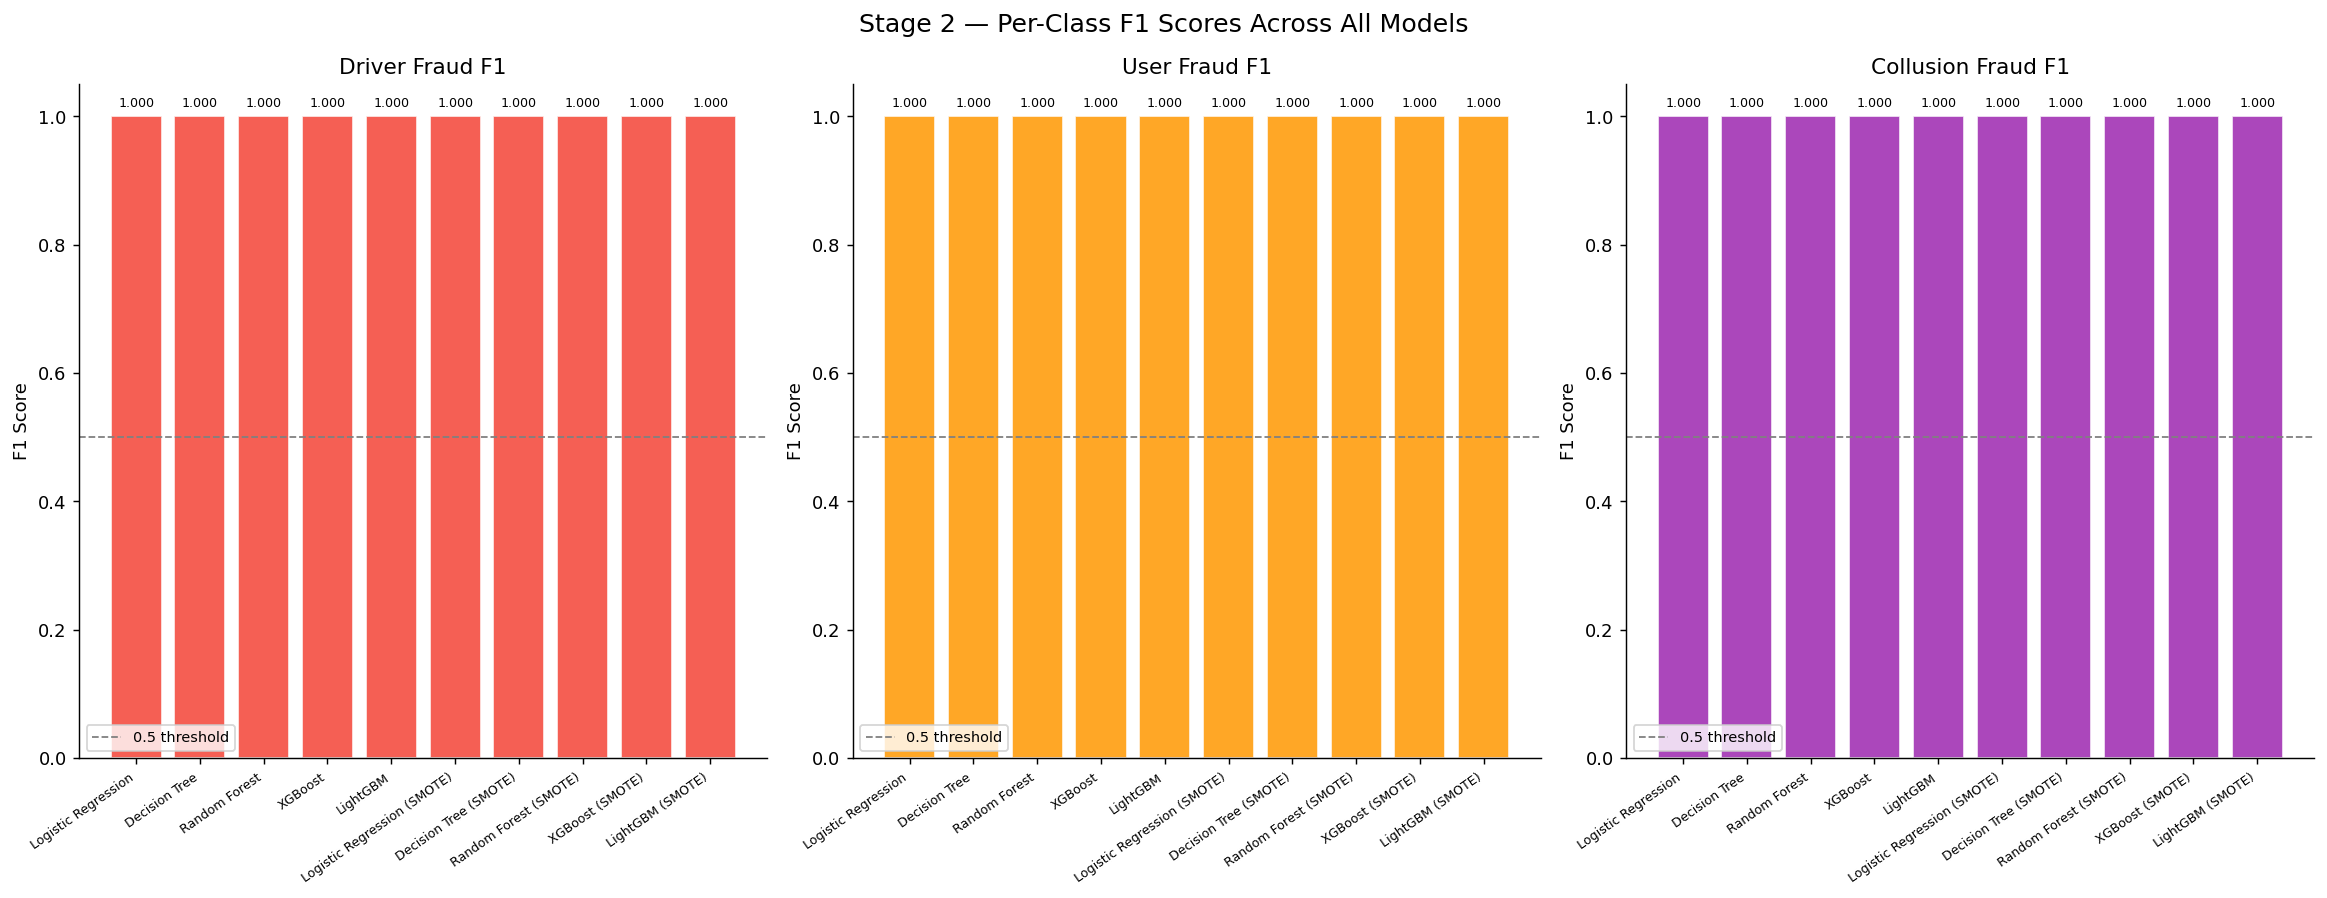

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Stage 2 — Per-Class F1 Scores Across All Models",
             fontsize=14)

model_names = results_s2_df["model"].tolist()
x = np.arange(len(model_names))

fraud_type_cols = [
    ("f1_driver_fraud",   "Driver Fraud F1",   FRAUD_COLORS[1]),
    ("f1_user_fraud",     "User Fraud F1",     FRAUD_COLORS[2]),
    ("f1_collusion_fraud","Collusion Fraud F1", FRAUD_COLORS[3]),
]

for idx, (col, title, color) in enumerate(fraud_type_cols):
    vals = results_s2_df[col].tolist()
    bars = axes[idx].bar(x, vals, color=color,
                         edgecolor="white", alpha=0.85)
    axes[idx].set_title(title)
    axes[idx].set_ylabel("F1 Score")
    axes[idx].set_ylim(0, 1.05)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(
        model_names, rotation=35, ha="right", fontsize=7
    )
    axes[idx].axhline(0.5, color="gray",
                      linestyle="--", linewidth=1,
                      label="0.5 threshold")
    axes[idx].legend(fontsize=8)
    for bar, v in zip(bars, vals):
        axes[idx].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{v:.3f}", ha="center", va="bottom", fontsize=7
        )

plt.tight_layout()
plt.savefig("../data/processed/model_s2_01_per_class_f1.png",
            dpi=150, bbox_inches="tight")
plt.show()

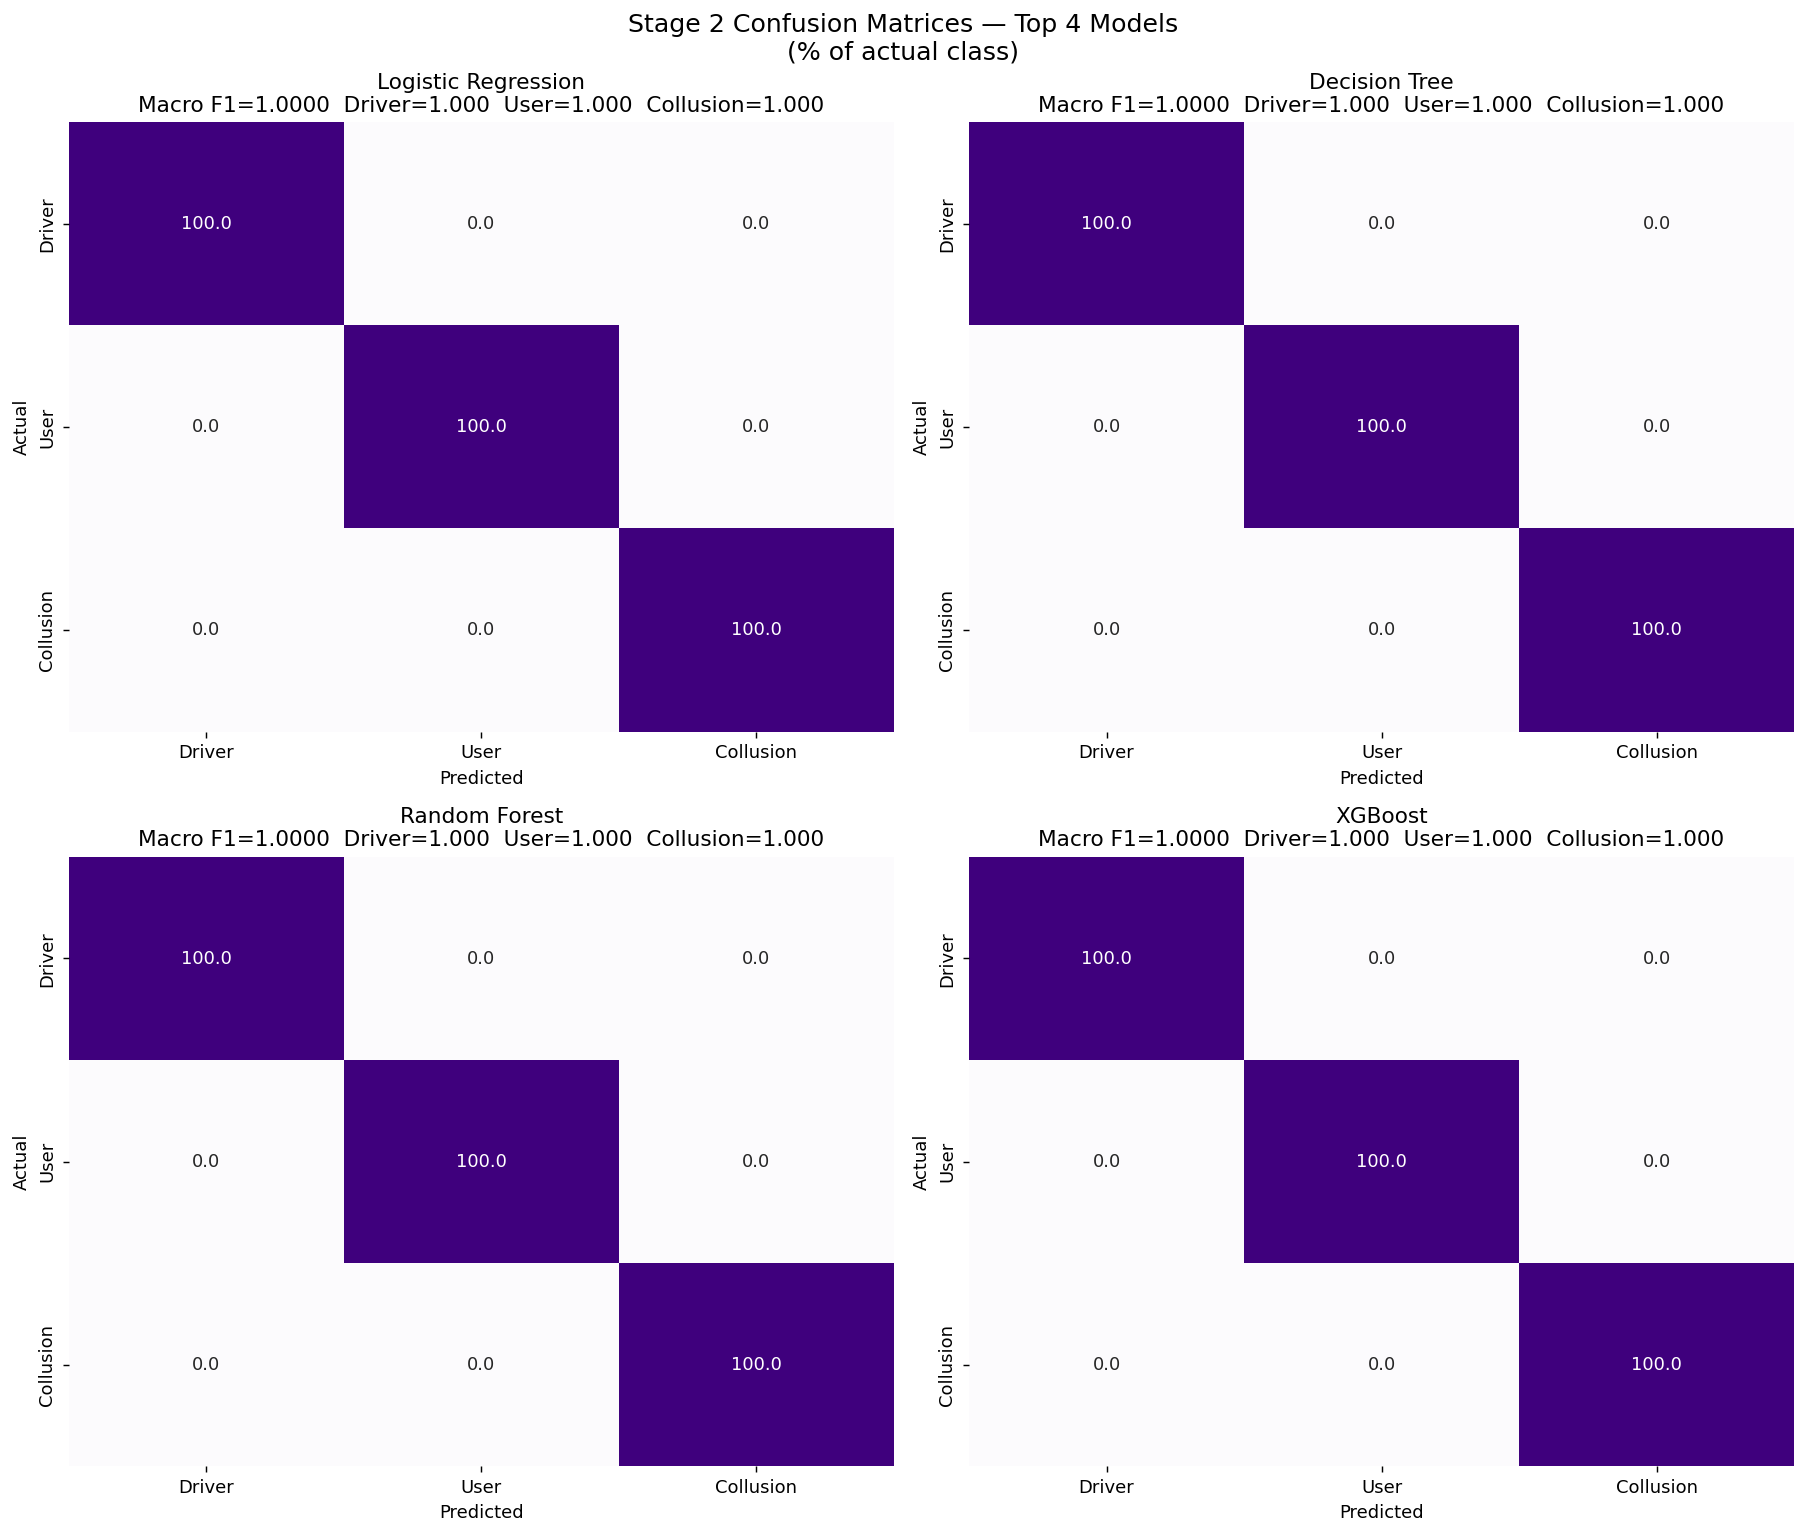

In [11]:
top4_s2 = results_s2_df.head(4)
top4_results_s2 = [
    next(r for r in all_s2_results
         if r["model"] == row["model"])
    for _, row in top4_s2.iterrows()
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Stage 2 Confusion Matrices — Top 4 Models\n"
             "(% of actual class)", fontsize=14)
axes = axes.flatten()

for idx, result in enumerate(top4_results_s2):
    y_true = result["y_test"]
    y_pred = result["y_pred"]

    cm     = confusion_matrix(y_true, y_pred, labels=[1,2,3])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(
        cm_pct, annot=True, fmt=".1f", cmap="Purples",
        xticklabels=["Driver","User","Collusion"],
        yticklabels=["Driver","User","Collusion"],
        ax=axes[idx], cbar=False
    )
    axes[idx].set_title(
        f"{result['model']}\n"
        f"Macro F1={result['macro_f1']:.4f}  "
        f"Driver={result['f1_driver_fraud']:.3f}  "
        f"User={result['f1_user_fraud']:.3f}  "
        f"Collusion={result['f1_collusion_fraud']:.3f}"
    )
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("../data/processed/model_s2_02_confusion_matrices.png",
            dpi=150, bbox_inches="tight")
plt.show()

5-Fold Stratified Cross Validation

⚠️ With only 1,831 rows, CV is MORE RELIABLE than single split

  Logistic Regression                 CV Macro F1: 1.0000 ± 0.0000  |  Single split: 1.0000
  Decision Tree                       CV Macro F1: 1.0000 ± 0.0000  |  Single split: 1.0000
  Random Forest                       CV Macro F1: 1.0000 ± 0.0000  |  Single split: 1.0000


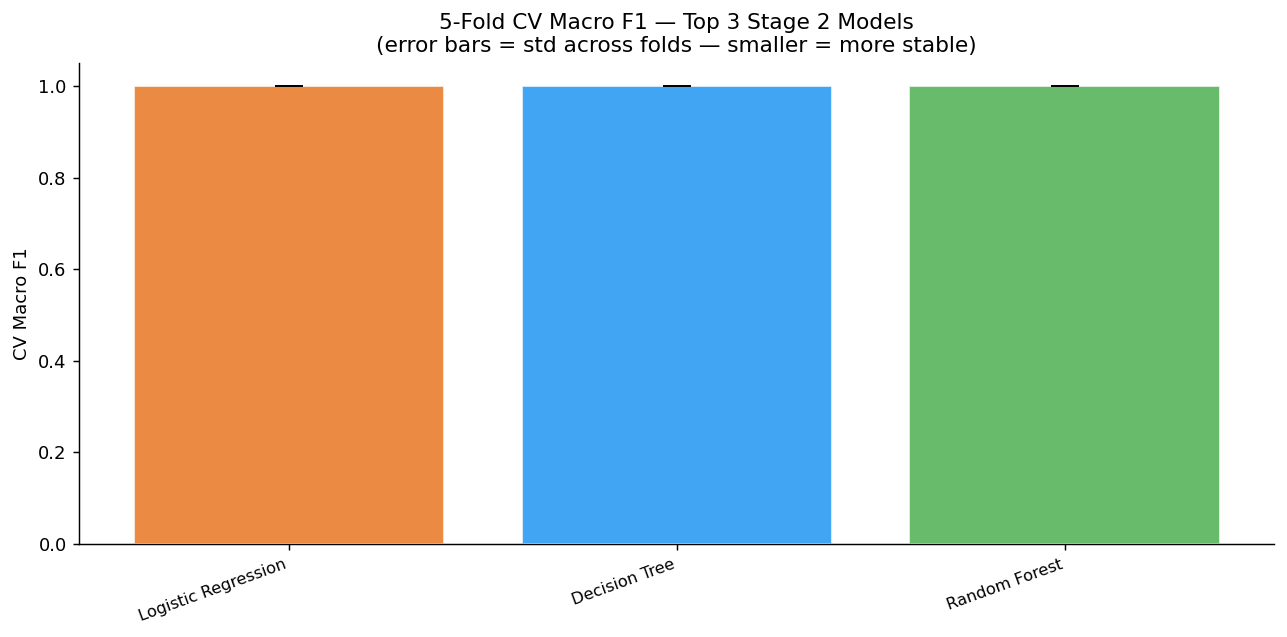

In [12]:
print("5-Fold Stratified Cross Validation\n")
print("⚠️ With only 1,831 rows, CV is MORE RELIABLE than single split\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Top 3 models from single split evaluation
top3_names = results_s2_df["model"].head(3).tolist()

cv_results_s2 = []

for model_name in top3_names:
    result = next(
        r for r in all_s2_results if r["model"] == model_name
    )
    model_obj = result["model_obj"]

    # Use SMOTE or original training data based on model name
    use_smote = "SMOTE" in model_name
    use_mapped = "XGBoost" in model_name or "LightGBM" in model_name

    X_full = X
    y_full = y.map(label_map) if use_mapped else y

    cv_scores = cross_val_score(
        model_obj, X_full, y_full,
        cv=skf,
        scoring="f1_macro",
        n_jobs=1  # use sequential evaluation in notebook to avoid multiprocessing child-process issues
    )

    cv_results_s2.append({
        "model"   : model_name,
        "cv_mean" : cv_scores.mean(),
        "cv_std"  : cv_scores.std(),
        "single_split_f1": result["macro_f1"],
    })

    print(f"  {model_name:<35} "
          f"CV Macro F1: {cv_scores.mean():.4f} ± "
          f"{cv_scores.std():.4f}  |  "
          f"Single split: {result['macro_f1']:.4f}")

cv_df = pd.DataFrame(cv_results_s2)

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(cv_df))
colors = ["#E87722","#2196F3","#4CAF50"]

ax.bar(x_pos, cv_df["cv_mean"], yerr=cv_df["cv_std"],
       color=colors, edgecolor="white", capsize=8, alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(cv_df["model"], rotation=20, ha="right", fontsize=9)
ax.set_title("5-Fold CV Macro F1 — Top 3 Stage 2 Models\n"
             "(error bars = std across folds — smaller = more stable)")
ax.set_ylabel("CV Macro F1")

plt.tight_layout()
plt.savefig("../data/processed/model_s2_03_cross_validation.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [18]:
best_s2_result = max(
    all_s2_results, key=lambda r: r["macro_f1"]
)

print("="*65)
print(f" BEST STAGE 2 MODEL: {best_s2_result['model']}")
print("="*65)
print(classification_report(
    best_s2_result["y_test"],
    best_s2_result["y_pred"],
    target_names=[FRAUD_LABELS[k] for k in [1,2,3]],
    zero_division=0
))

print("\nKey business interpretation:")
print(f"  Driver Fraud F1   : {best_s2_result['f1_driver_fraud']:.4f}")
print(f"  User Fraud F1     : {best_s2_result['f1_user_fraud']:.4f}")
print(f"  Collusion Fraud F1: {best_s2_result['f1_collusion_fraud']:.4f}")
print(f"\n  Hardest class     : "
      f"{'User Fraud' if best_s2_result['f1_user_fraud'] < best_s2_result['f1_driver_fraud'] else 'Other'}")

 BEST STAGE 2 MODEL: Logistic Regression
                 precision    recall  f1-score   support

   Driver Fraud       1.00      1.00      1.00       145
     User Fraud       1.00      1.00      1.00       123
Collusion Fraud       1.00      1.00      1.00        99

       accuracy                           1.00       367
      macro avg       1.00      1.00      1.00       367
   weighted avg       1.00      1.00      1.00       367


Key business interpretation:
  Driver Fraud F1   : 1.0000
  User Fraud F1     : 1.0000
  Collusion Fraud F1: 1.0000

  Hardest class     : Other


In [20]:
best_s2_model_obj = best_s2_result["model_obj"]

if hasattr(best_s2_model_obj, "feature_importances_"):
    importances_s2 = pd.Series(
        best_s2_model_obj.feature_importances_,
        index=feature_cols_s2
    ).sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.Purples(
        np.linspace(0.4, 0.9, len(importances_s2))
    )[::-1]

    ax.barh(importances_s2.index, importances_s2.values,
            color=colors, edgecolor="white")
    ax.set_title(
        f"Stage 2 Feature Importance — {best_s2_result['model']}\n"
        f"(distinguishing BETWEEN fraud types)",
        fontsize=12
    )
    ax.set_xlabel("Importance Score")
    ax.invert_yaxis()

    plt.tight_layout()
    plt.savefig("../data/processed/model_s2_04_feature_importance.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Top 10 Stage 2 features:")
    print(importances_s2.head(10).round(5))

    print(f"\nExpected top features for Stage 2:")
    print(f"  is_high_velocity_driver → separates Driver from others")
    print(f"  is_collusion_suspect    → separates Collusion from others")
    print(f"  gps signals             → separate Driver from User")
    top3 = importances_s2.head(3).index.tolist()
    print(f"\n  Model says top 3: {top3}")

In [21]:
import os
MODELS_DIR = "../models/"
os.makedirs(MODELS_DIR, exist_ok=True)

best_s2_name = best_s2_result["model"]
s2_filename  = (
    f"{best_s2_name.lower().replace(' ','_').replace('(','').replace(')','')}"
    f"_stage2_fraud.pkl"
)

with open(MODELS_DIR + s2_filename, "wb") as f:
    pickle.dump(best_s2_model_obj, f)

results_s2_df.drop(
    columns=["model_obj","y_pred","y_test"], errors="ignore"
).to_csv(PATH + "stage2_model_results.csv", index=False)

print(f"✅ Best Stage 2 model saved: models/{s2_filename}")
print(f"✅ Results saved: data/processed/stage2_model_results.csv")

✅ Best Stage 2 model saved: models/logistic_regression_stage2_fraud.pkl
✅ Results saved: data/processed/stage2_model_results.csv
